# Notebook 05 — Machine Learning Models

**Purpose:** Train and compare ML models to predict next-day EUR/USD direction.

## Models

| Model | Type | Strength |
|---|---|---|
| Random Forest | Bagging ensemble | Stable baseline, robust to overfitting |
| XGBoost | Gradient boosting | Often best for tabular data |
| LightGBM | Gradient boosting | Fast, handles many features well |

## Evaluation

- **Directional Accuracy** (primary): % of correct UP/DOWN predictions
- Precision, Recall, F1-score
- Confusion matrix
- Comparison vs naive baseline (50.26%)

## Input → Output

- **Input:** `data/processed/fx_features.csv` (4085 × 34)
- **Output:** trained models saved to `models/` (`.pkl`)

## Critical Rule

We re-apply the SAME chronological split as Notebook 04:
- Train: 2010-2021
- Val: 2022-2024
- Test: 2025-2026

No shuffling → no look-ahead bias.

---

**Author:** Dong Cong Gia Khang
**Date:** June 2026

## 1. Setup

In [3]:
"""
Setup imports and paths.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root(marker=".env"):
    """Find project root by looking for a marker file."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = PROJECT_ROOT / "figures" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed:    {PROCESSED_DIR}")
print(f"Models:       {MODELS_DIR}")
print(f"Figures:      {FIG_DIR}")

Project root: c:\Users\Khang\Desktop\Final Project 2
Processed:    c:\Users\Khang\Desktop\Final Project 2\data\processed
Models:       c:\Users\Khang\Desktop\Final Project 2\models
Figures:      c:\Users\Khang\Desktop\Final Project 2\figures\models


## 2. Load Features & Chronological Split (70/20/10)

Load the engineered feature set and split chronologically by position:
first 70% → train, next 20% → validation, last 10% → test.
No shuffling → no look-ahead bias.

In [4]:
"""
Load engineered features.
"""
df = pd.read_csv(PROCESSED_DIR / "fx_features.csv", parse_dates=["date"])

feature_cols = [c for c in df.columns
                if c not in ["date", "target_return_next_day", "target_direction"]]

print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Features: {len(feature_cols)}")

Loaded: 4084 rows x 34 cols
Date range: 2010-02-02 -> 2026-05-12
Features: 31


In [5]:
"""
Chronological 70/20/10 positional split.
"""
n = len(df)
i70, i90 = int(n * 0.70), int(n * 0.90)

train = df.iloc[:i70].reset_index(drop=True)
val   = df.iloc[i70:i90].reset_index(drop=True)
test  = df.iloc[i90:].reset_index(drop=True)

print("CHRONOLOGICAL SPLIT 70/20/10")
print("=" * 64)
for name, d in [("Train", train), ("Val", val), ("Test", test)]:
    print(f"{name:5s}: {len(d):5d} rows ({len(d)/n*100:.1f}%)  "
          f"{d['date'].min().date()} -> {d['date'].max().date()}  "
          f"UP {d['target_direction'].mean()*100:.2f}%")
print("=" * 64)

test_up = test["target_direction"].mean()
test_baseline = max(test_up, 1 - test_up)
print(f"Test majority-class baseline: {test_baseline*100:.2f}% "
      f"(majority = {'UP' if test_up > 0.5 else 'DOWN'})")
print("-> Models must beat this baseline to add value.")

CHRONOLOGICAL SPLIT 70/20/10
Train:  2858 rows (70.0%)  2010-02-02 -> 2021-06-23  UP 50.14%
Val  :   817 rows (20.0%)  2021-06-24 -> 2024-09-23  UP 49.33%
Test :   409 rows (10.0%)  2024-09-24 -> 2026-05-12  UP 44.99%
Test majority-class baseline: 55.01% (majority = DOWN)
-> Models must beat this baseline to add value.


## 3. Evaluation Helper

Every model is evaluated the same way: accuracy on train/val/test,
compared against the majority-class baselines. Results are stored
for the final comparison table.

In [6]:
"""
Shared evaluation helper.
"""
from sklearn.metrics import accuracy_score

X_train, y_train = train[feature_cols], train["target_direction"]
X_val,   y_val   = val[feature_cols],   val["target_direction"]
X_test,  y_test  = test[feature_cols],  test["target_direction"]

VAL_BASE  = max(y_val.mean(),  1 - y_val.mean())
TEST_BASE = max(y_test.mean(), 1 - y_test.mean())

results = {}

def evaluate_model(name, model):
    """Report accuracy on all splits vs majority baselines."""
    acc_tr = accuracy_score(y_train, model.predict(X_train))
    acc_va = accuracy_score(y_val,   model.predict(X_val))
    acc_te = accuracy_score(y_test,  model.predict(X_test))
    results[name] = {"train": acc_tr, "val": acc_va, "test": acc_te}
    print(f"=== {name} ===")
    print(f"Train: {acc_tr*100:5.2f}%   (overfit check)")
    print(f"Val:   {acc_va*100:5.2f}%   vs baseline {VAL_BASE*100:.2f}%  ({(acc_va-VAL_BASE)*100:+.2f} pp)")
    print(f"Test:  {acc_te*100:5.2f}%   vs baseline {TEST_BASE*100:.2f}%  ({(acc_te-TEST_BASE)*100:+.2f} pp)")
    return model

print(f"Helper ready. Val baseline: {VAL_BASE*100:.2f}% | Test baseline: {TEST_BASE*100:.2f}%")

Helper ready. Val baseline: 50.67% | Test baseline: 55.01%


## 4. Model 1 — Random Forest

Bagging ensemble of decision trees. Stable baseline, hard to overfit
with controlled depth, and provides feature importance.

In [7]:
"""
Train Random Forest.
"""
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,      # 300 trees vote together
    max_depth=6,           # shallow trees -> control overfitting
    min_samples_leaf=20,   # each leaf needs 20+ samples (noisy financial data)
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf = evaluate_model("Random Forest", rf)

=== Random Forest ===
Train: 75.89%   (overfit check)
Val:   51.53%   vs baseline 50.67%  (+0.86 pp)
Test:  47.92%   vs baseline 55.01%  (-7.09 pp)


In [8]:
"""
LEAKAGE DIAGNOSTIC
83-86% accuracy is far above the published ceiling (~58.5%)
for this task -> verify alignment before trusting anything.
"""
import numpy as np

print("1) Target construction check")
recon = df["eurusd_return"].shift(-1)
diff = (df["target_return_next_day"] - recon).abs().max()
print(f"   max |target - eurusd_return.shift(-1)| = {diff}")
print("   -> phai = 0.0 neu target dung la return NGAY MAI cua cot nay\n")

print("2) Same-day vs next-day correlation (smoking-gun test)")
c_same  = df["dxy_return"].corr(df["eurusd_return"])
c_next  = df["dxy_return"].corr(df["target_return_next_day"])
c_self  = df["eurusd_return"].corr(df["target_return_next_day"])
print(f"   corr(dxy_return, eurusd_return CUNG ngay) = {c_same:+.3f}   (ky vong ~ -0.95)")
print(f"   corr(dxy_return, target NGAY MAI)         = {c_next:+.3f}   (ky vong ~  0.00)")
print(f"   corr(eurusd_return, target NGAY MAI)      = {c_self:+.3f}   (ky vong ~  0.00)\n")

print("3) Direction consistency")
implied = (df["target_return_next_day"] > 0).astype(int)
mismatch = (implied != df["target_direction"]).mean()
print(f"   mismatch direction vs sign(next-day return) = {mismatch*100:.2f}%\n")

print("4) Feature-vs-target correlation scan (|corr| > 0.30 = nghi pham leak)")
corrs = df[feature_cols].corrwith(df["target_return_next_day"]).abs().sort_values(ascending=False)
print(corrs.head(10).round(3))

1) Target construction check
   max |target - eurusd_return.shift(-1)| = 0.0041268512631504
   -> phai = 0.0 neu target dung la return NGAY MAI cua cot nay

2) Same-day vs next-day correlation (smoking-gun test)
   corr(dxy_return, eurusd_return CUNG ngay) = -0.830   (ky vong ~ -0.95)
   corr(dxy_return, target NGAY MAI)         = -0.003   (ky vong ~  0.00)
   corr(eurusd_return, target NGAY MAI)      = -0.026   (ky vong ~  0.00)

3) Direction consistency
   mismatch direction vs sign(next-day return) = 0.00%

4) Feature-vs-target correlation scan (|corr| > 0.30 = nghi pham leak)
eurusd_return_ma10      0.031
gold_return_lag1        0.028
eurusd_return_lag2      0.028
eur_net_position_pct    0.026
eurusd_return           0.026
vixcls_diff_lag1        0.024
t10yie_diff             0.023
ecbdfr_diff             0.023
eurusd_return_ma5       0.021
vix_regime              0.019
dtype: float64


## 5. Model 2 — XGBoost

Gradient boosting: trees built sequentially, each correcting the previous.
Shallow trees (depth 3) + slow learning rate to resist noise.

In [9]:
"""
Train XGBoost.
"""
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=3,            # shallow -> noise-resistant
    learning_rate=0.03,     # slow, steady learning
    subsample=0.8,          # row sampling -> regularization
    colsample_bytree=0.8,   # feature sampling
    min_child_weight=20,
    reg_lambda=2.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)
xgb = evaluate_model("XGBoost", xgb)

=== XGBoost ===
Train: 76.24%   (overfit check)
Val:   50.43%   vs baseline 50.67%  (-0.24 pp)
Test:  44.01%   vs baseline 55.01%  (-11.00 pp)


## 6. Model 3 — LightGBM

Faster gradient boosting variant; comparison against XGBoost.

In [10]:
"""
Train LightGBM.
"""
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=400,
    max_depth=3,
    num_leaves=7,           # 2^3 - 1 -> matches depth 3
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(X_train, y_train)
lgbm = evaluate_model("LightGBM", lgbm)

=== LightGBM ===
Train: 78.31%   (overfit check)
Val:   51.90%   vs baseline 50.67%  (+1.22 pp)
Test:  45.72%   vs baseline 55.01%  (-9.29 pp)


## 7. Model Comparison

               Train %  Val %  Test %
Random Forest    75.89  51.53   47.92
XGBoost          76.24  50.43   44.01
LightGBM         78.31  51.90   45.72

Val baseline:  50.67%   |   Test baseline: 55.01%


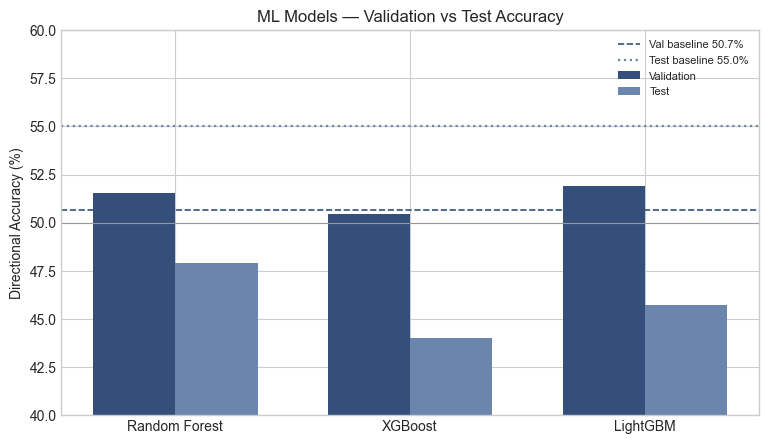

In [11]:
"""
Compare all models against baselines.
"""
comp = pd.DataFrame(results).T * 100
comp = comp[["train", "val", "test"]].round(2)
comp.columns = ["Train %", "Val %", "Test %"]
print(comp.to_string())
print(f"\nVal baseline:  {VAL_BASE*100:.2f}%   |   Test baseline: {TEST_BASE*100:.2f}%")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comp))
w = 0.35
ax.bar(x - w/2, comp["Val %"],  w, label="Validation", color="#34507a")
ax.bar(x + w/2, comp["Test %"], w, label="Test", color="#6b86ad")
ax.axhline(VAL_BASE*100,  color="#34507a", ls="--", lw=1.2, label=f"Val baseline {VAL_BASE*100:.1f}%")
ax.axhline(TEST_BASE*100, color="#6b86ad", ls=":",  lw=1.6, label=f"Test baseline {TEST_BASE*100:.1f}%")
ax.axhline(50, color="#999999", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(comp.index)
ax.set_ylabel("Directional Accuracy (%)")
ax.set_ylim(40, 60)
ax.set_title("ML Models — Validation vs Test Accuracy")
ax.legend(fontsize=8)
plt.savefig(FIG_DIR / "05_model_comparison.png")
plt.show()

## 8. Confidence Filtering

Instead of predicting every day, only act when the model's predicted
probability is far from 0.5. Accuracy on those "confident days" is how
practitioners extract value from a thin edge (trade-off: lower coverage).
Threshold is chosen on VALIDATION only; test is touched once.

In [12]:
"""
Accuracy vs coverage at confidence thresholds (best model by VAL).
"""
best_name = max(results, key=lambda k: results[k]["val"])
best_model = {"Random Forest": rf, "XGBoost": xgb, "LightGBM": lgbm}[best_name]
print(f"Best by validation: {best_name}\n")

def confidence_table(model, X, y, label):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    conf = np.abs(proba - 0.5)
    print(f"--- {label} ---")
    print(f"{'thresh':>7} {'coverage':>9} {'n_days':>7} {'accuracy':>9}")
    for t in [0.00, 0.02, 0.04, 0.06, 0.08, 0.10]:
        mask = conf >= t
        n = int(mask.sum())
        if n < 20:
            print(f"{0.5+t:>7.2f} {'-':>9} {n:>7}   (qua it mau)")
            continue
        acc = (pred[mask] == y.values[mask]).mean()
        print(f"{0.5+t:>7.2f} {n/len(y)*100:>8.1f}% {n:>7} {acc*100:>8.2f}%")
    print()

confidence_table(best_model, X_val, y_val, "VALIDATION")
confidence_table(best_model, X_test, y_test, "TEST")

Best by validation: LightGBM

--- VALIDATION ---
 thresh  coverage  n_days  accuracy
   0.50    100.0%     817    51.90%
   0.52     84.1%     687    52.40%
   0.54     67.6%     552    52.90%
   0.56     54.8%     448    53.12%
   0.58     42.5%     347    53.03%
   0.60     30.2%     247    53.85%

--- TEST ---
 thresh  coverage  n_days  accuracy
   0.50    100.0%     409    45.72%
   0.52     79.2%     324    45.37%
   0.54     63.8%     261    43.68%
   0.56     49.6%     203    42.86%
   0.58     34.7%     142    45.07%
   0.60     24.4%     100    41.00%



## 9. Save Models

In [13]:
"""
Persist trained models (for comparison, backtest, live demo).
"""
import joblib

for name, model in [("random_forest", rf), ("xgboost", xgb), ("lightgbm", lgbm)]:
    joblib.dump(model, MODELS_DIR / f"{name}.pkl")
    print(f"Saved {name}.pkl")

comp.to_csv(MODELS_DIR / "ml_results.csv")
print("Saved ml_results.csv")

Saved random_forest.pkl
Saved xgboost.pkl
Saved lightgbm.pkl
Saved ml_results.csv
